# Merging and Enrichment: Building a County-Level Master Dataset

## Overview
Models cannot learn from four separate datasets. This notebook:
1. Merges all four cleaned datasets into a single master table.
2. Aggregates facility-level data to the county level.
3. Enriches with population data and calculates per-capita metrics.
4. Creates a composite health infrastructure score.
5. Explores relationships between variables.

The goal is to create a unified dataset for analyzing geographic accessibility
and identifying potential infrastructure bias across Kenyan counties.


In [4]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

 
warnings.filterwarnings('ignore')
 
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [5]:
# Load all four cleaned datasets from the processed folder
health_units   = pd.read_csv('../data/processed/health_units_clean.csv')
pharmacies     = pd.read_csv('../data/processed/pharmacies_clean.csv')
hospitals_beds = pd.read_csv('../data/processed/hospitals_and_beds_clean.csv')
county_beds    = pd.read_csv('../data/processed/county_beds_clean.csv')

In [6]:

print(f'  health_units:   {health_units.shape}')
print(f'  pharmacies:     {pharmacies.shape}')
print(f'  hospitals_beds: {hospitals_beds.shape}')
print(f'  county_beds:    {county_beds.shape}')

  health_units:   (5558, 9)
  pharmacies:     (5219, 27)
  hospitals_beds: (12394, 26)
  county_beds:    (47, 2)


In [7]:

county_name_fixes = {
    'elgeyo marakwet': 'elgeyo-marakwet',
    'muranga':         "murang'a",
    'tharaka nithi':   'tharaka-nithi'
}
def standardise_county(name):
    name = str(name).strip().lower()
    return county_name_fixes.get(name, name)


In [8]:

health_units['Facility_county'] = health_units['Facility_county'].apply(standardise_county)
pharmacies['County'] = pharmacies['County'].apply(standardise_county)
hospitals_beds['County']  = hospitals_beds['County'].apply(standardise_county)
county_beds['County'] = county_beds['County'].apply(standardise_county)



In [11]:

total_facilities = (hospitals_beds.groupby('County').size().reset_index(name='Total_facilities'))
 
print('Shape:', total_facilities.shape)
print(total_facilities.sort_values('Total_facilities', ascending=False).head(5))

Shape: (47, 2)
     County  Total_facilities
29  nairobi              1005
12   kiambu               666
30   nakuru               562
25     meru               529
17    kitui               446


In [13]:

status_summary = ( health_units.groupby(['Facility_county', 'Status']).size().unstack(fill_value=0).reset_index())
 
status_summary.columns.name = None
status_summary = status_summary.rename(columns={'Facility_county': 'County'})
print(status_summary)

             County  closed  fully-functional  non-functional  semi-functional
0           baringo       0                23              23               11
1             bomet       0                49               0               69
2           bungoma       0               224               2               91
3             busia       0               182               0                3
4   elgeyo-marakwet       0                11              32               19
5              embu       3                34               1                7
6           garissa       0                67               1                9
7          homa bay       1               231              10               35
8            isiolo       0                 2               4               17
9           kajiado       0                81              10               15
10         kakamega       0               255               4              174
11          kericho       0                12       

In [ ]:

status_cols = [c for c in status_summary.columns if c != 'County']
status_summary['Total_health_units'] = status_summary[status_cols].sum(axis=1)
 
status_summary['Pct_fully_functional'] = (status_summary.get('fully-functional', 0) / status_summary['Total_health_units'] * 100).round(1)
 
status_summary['Pct_non_functional'] = (status_summary.get('non-functional', 0) / status_summary['Total_health_units'] * 100).round(1)
 
print('Shape:', status_summary.shape)
print('Columns:', list(status_summary.columns))

print('\nCounties with lowest fully-functional rate:')
print(status_summary[['County', 'Pct_fully_functional']].sort_values('Pct_fully_functional').head())
 

Shape: (47, 8)
Columns: ['County', 'closed', 'fully-functional', 'non-functional', 'semi-functional', 'Total_health_units', 'Pct_fully_functional', 'Pct_non_functional']

Counties with lowest fully-functional rate:
             County  Pct_fully_functional
8            isiolo                   8.7
21         machakos                  16.8
4   elgeyo-marakwet                  17.7
22          makueni                  36.3
46       west pokot                  37.1


In [16]:

 
pharmacy_counts = (pharmacies.groupby('County').size().reset_index(name='Total_pharmacies'))

print(pharmacy_counts)

             County  Total_pharmacies
0           baringo               182
1             bomet               123
2           bungoma               124
3             busia                70
4   elgeyo-marakwet                93
5              embu               110
6           garissa                63
7          homa bay               144
8            isiolo                45
9           kajiado                94
10         kakamega               130
11          kericho               158
12           kiambu               132
13           kilifi               141
14        kirinyaga                77
15            kisii                83
16           kisumu                76
17            kitui               290
18            kwale               111
19         laikipia                85
20             lamu                31
21         machakos               165
22          makueni               210
23          mandera                58
24         marsabit                67
25          

In [19]:

registered_pharmacies = (pharmacies.groupby('County')['Is_registered'].sum().reset_index(name='Registered_pharmacies'))
 
pharmacy_summary = pharmacy_counts.merge(registered_pharmacies, on='County')
pharmacy_summary['Pct_pharmacies_registered'] = (pharmacy_summary['Registered_pharmacies'] / pharmacy_summary['Total_pharmacies'] * 100).round(1)
 
print('Shape:', pharmacy_summary.shape)
print(pharmacy_summary.head(10))

Shape: (47, 4)
            County  Total_pharmacies  Registered_pharmacies  \
0          baringo               182                      1   
1            bomet               123                      4   
2          bungoma               124                      1   
3            busia                70                      2   
4  elgeyo-marakwet                93                     17   
5             embu               110                      4   
6          garissa                63                      1   
7         homa bay               144                      5   
8           isiolo                45                      3   
9          kajiado                94                      2   

   Pct_pharmacies_registered  
0                        0.5  
1                        3.3  
2                        0.8  
3                        2.9  
4                       18.3  
5                        3.6  
6                        1.6  
7                        3.5  
8           

In [26]:

hospitals_beds['Is_public'] = (hospitals_beds['Owner type'].str.lower().str.contains('public', na=False))
 
ownership_summary = (hospitals_beds.groupby('County').agg(Public_facilities  = ('Is_public', 'sum'),Total_for_ownership = ('Is_public', 'count')).reset_index())
print(f"Ownership summary")
print(ownership_summary)
ownership_summary['Public_facility_ratio'] = (ownership_summary['Public_facilities'] / ownership_summary['Total_for_ownership']).round(3)

 
print('Shape:', ownership_summary.shape)

print('\nCounties with lowest public facility ratio (most privatised):')
print(ownership_summary[['County', 'Public_facility_ratio']]
      .sort_values('Public_facility_ratio')
      .head(5))

Ownership summary
             County  Public_facilities  Total_for_ownership
0           baringo                  0                  251
1             bomet                  0                  188
2           bungoma                  0                  244
3             busia                  0                  157
4   elgeyo-marakwet                  0                  134
5              embu                  0                  218
6           garissa                  0                  184
7          homa bay                  0                  328
8            isiolo                  0                   69
9           kajiado                  0                  346
10         kakamega                  0                  332
11          kericho                  0                  234
12           kiambu                  0                  666
13           kilifi                  0                  348
14        kirinyaga                  0                  264
15            kisii   

In [27]:

 
beds_summary = (hospitals_beds.groupby('County').agg(Facility_reported_beds  = ('Beds', 'sum'),Suspect_zero_bed_count  = ('Beds_data_suspect', 'sum')).reset_index())
 
print('Shape:', beds_summary.shape)
print(beds_summary.head())

Shape: (47, 3)
            County  Facility_reported_beds  Suspect_zero_bed_count
0          baringo                   820.0                       9
1            bomet                   849.0                      11
2          bungoma                  2038.0                       3
3            busia                  1314.0                       2
4  elgeyo-marakwet                   858.0                      15


In [34]:

master = county_beds.copy()
 

master = master.merge(total_facilities,  on='County', how='left')
master = master.merge(status_summary,    on='County', how='left')
master = master.merge(pharmacy_summary,  on='County', how='left')
master = master.merge(ownership_summary, on='County', how='left')
master = master.merge(beds_summary,      on='County', how='left')
 
print('Master table shape:', master.shape)
print(list(master.columns))
print()

nulls = master.isnull().sum()
print(f"Sum of null counties: {nulls.sum()}")



Master table shape: (47, 18)
['County', 'Total_beds', 'Total_facilities', 'closed', 'fully-functional', 'non-functional', 'semi-functional', 'Total_health_units', 'Pct_fully_functional', 'Pct_non_functional', 'Total_pharmacies', 'Registered_pharmacies', 'Pct_pharmacies_registered', 'Public_facilities', 'Total_for_ownership', 'Public_facility_ratio', 'Facility_reported_beds', 'Suspect_zero_bed_count']

Sum of null counties: 0


In [36]:

# map to county population
county_population = {
    'baringo': 666763, 'bomet': 875689, 'bungoma': 1670570,
    'busia': 893681, 'elgeyo-marakwet': 454480, 'embu': 608599,
    'garissa': 841353, 'homa bay': 1131950, 'isiolo': 268002,
    'kajiado': 1117840, 'kakamega': 1867579, 'kericho': 901777,
    'kiambu': 2417735, 'kilifi': 1453787, 'kirinyaga': 610411,
    'kisii': 1266860, 'kisumu': 1155574, 'kitui': 1136187,
    'kwale': 866820, 'laikipia': 518560, 'lamu': 143920,
    'machakos': 1421932, 'makueni': 987653, 'mandera': 867457,
    'marsabit': 459785, 'meru': 1545714, 'migori': 1116436,
    'mombasa': 1208333, "murang'a": 1056640, 'nairobi': 4397073,
    'nakuru': 2162202, 'nandi': 885711, 'narok': 1157873,
    'nyamira': 605576, 'nyandarua': 638289, 'nyeri': 759164,
    'samburu': 310327, 'siaya': 993183, 'taita taveta': 340671,
    'tana river': 315943, 'tharaka-nithi': 393177, 'trans nzoia': 1030206,
    'turkana': 926975, 'uasin gishu': 1163186, 'vihiga': 590013,
    'wajir': 781263, 'west pokot': 621241
}
 
master['Population'] = master['County'].map(county_population)
 

missing_pop = master[master['Population'].isnull()]['County'].tolist()
print(missing_pop)


[]


In [41]:

# Create a measure by WHO for beds per 10000 people 
master['Beds_per_10k'] = (
    master['Total_beds'] / master['Population'] * 10000
).round(2)

In [38]:

 # Create a measure by WHO for facilities per 10000 people 
master['Facilities_per_10k'] = (
    master['Total_facilities'] / master['Population'] * 10000
).round(2)

In [39]:
 # Create a measure by WHO for pharmacies per 10000 people 
master['Pharmacies_per_10k'] = (
    master['Total_pharmacies'] / master['Population'] * 10000
).round(2)

In [ ]:
# Counties below WHO bed threshold (10 per 10,000 people
below_threshold = master[master['Beds_per_10k'] < 10][['County', 'Beds_per_10k', 'Population']]
print(below_threshold.sort_values('Beds_per_10k').to_string(index=False))

     County  Beds_per_10k  Population
      kwale          6.01      866820
     kilifi          6.99     1453787
      wajir          7.69      781263
trans nzoia          8.28     1030206
 west pokot          8.97      621241
  nyandarua          9.21      638289
    turkana          9.37      926975
   murang'a          9.44     1056640
      nandi          9.47      885711
      bomet          9.65      875689


In [43]:
def normalise(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0
    return (series - min_val) / (max_val - min_val)
 
master['Score_beds'] = normalise(master['Beds_per_10k'])
master['Score_functional'] = normalise(master['Pct_fully_functional'])
master['Score_public'] = master['Public_facility_ratio']
 
master['Infrastructure_score'] = ((master['Score_beds'] + master['Score_functional'] + master['Score_public']) / 3).round(3)
 
print('\nTop 5 counties by infrastructure score:')
print(master[['County', 'Infrastructure_score']].sort_values('Infrastructure_score', ascending=False).head().to_string(index=False))
 

print('\nBottom 5 counties by infrastructure score:')
print(master[['County', 'Infrastructure_score']].sort_values('Infrastructure_score').head().to_string(index=False))
 


Top 5 counties by infrastructure score:
       County  Infrastructure_score
tharaka-nithi                 0.603
         embu                 0.568
       migori                 0.555
        nyeri                 0.543
        kisii                 0.537

Bottom 5 counties by infrastructure score:
     County  Infrastructure_score
 west pokot                 0.147
      bomet                 0.173
   machakos                 0.196
trans nzoia                 0.197
      narok                 0.202


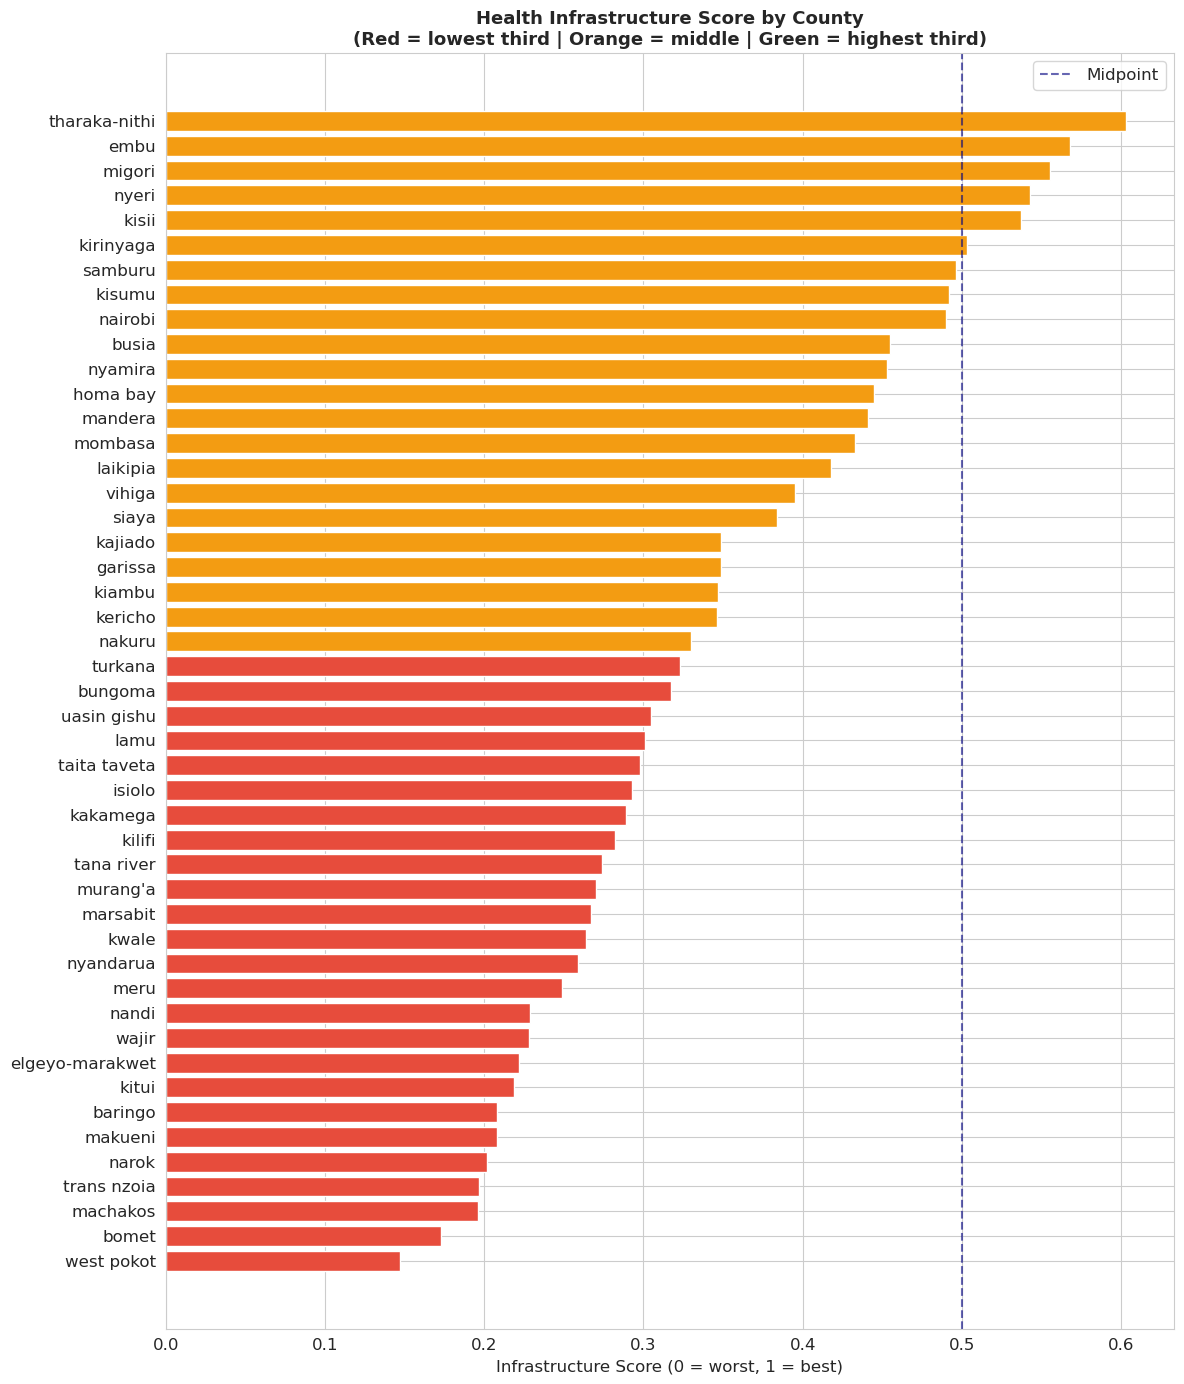

In [ ]:

 
sorted_master = master.sort_values('Infrastructure_score', ascending=True)
 
colors = [
    '#e74c3c' if s < 0.33 else '#f39c12' if s < 0.66 else '#2ecc71'
    for s in sorted_master['Infrastructure_score']
]
 
plt.figure(figsize=(12, 14))
plt.barh(sorted_master['County'], sorted_master['Infrastructure_score'],
         color=colors, edgecolor='white')
plt.axvline(x=0.5, color='navy', linestyle='--', alpha=0.6, label='Midpoint')
plt.title('Health Infrastructure Score by County\n'
          '(Red = lowest third | Orange = middle | Green = highest third)',
          fontsize=13, fontweight='bold')
plt.xlabel('Infrastructure Score (0 = worst, 1 = best)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/infrastructure_score_by_county.png', dpi=150)
plt.show()


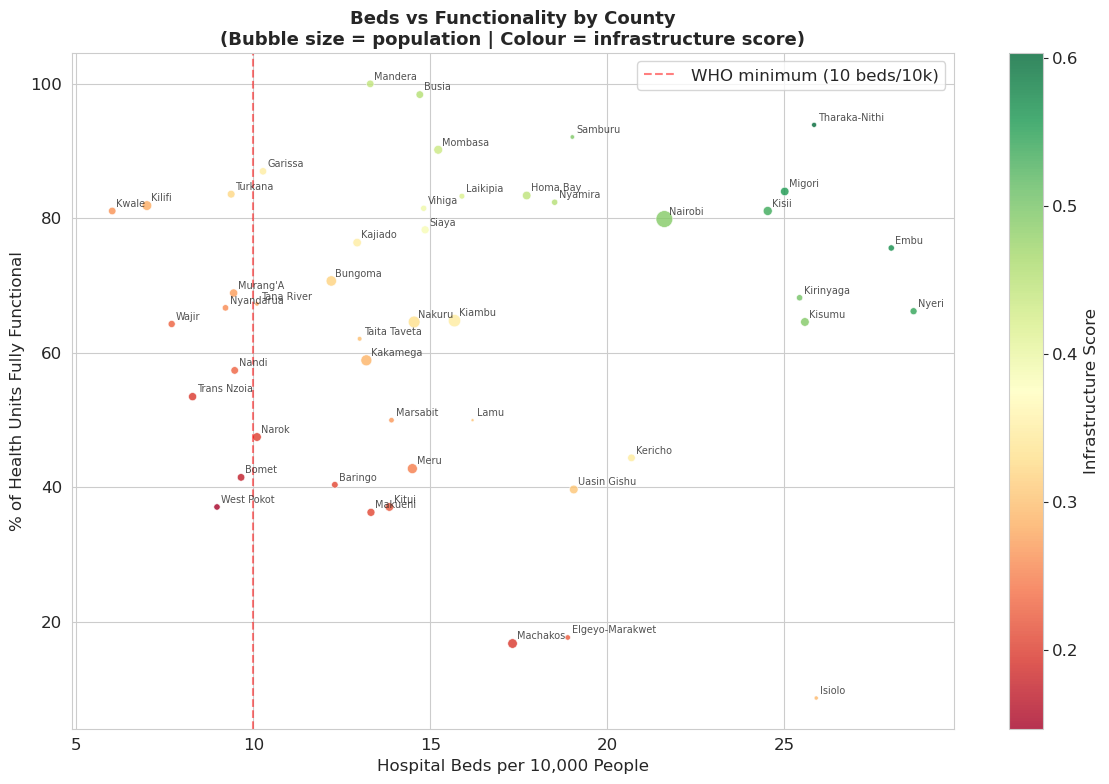

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
 
scatter = ax.scatter(
    master['Beds_per_10k'],
    master['Pct_fully_functional'],
    s=master['Population'] / 30000,
    c=master['Infrastructure_score'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)
 
# Label each dot with county name
for _, row in master.iterrows():
    ax.annotate(
        row['County'].title(),
        (row['Beds_per_10k'], row['Pct_fully_functional']),
        fontsize=7,
        alpha=0.8,
        xytext=(3, 3),
        textcoords='offset points'
    )
 
plt.colorbar(scatter, label='Infrastructure Score')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='WHO minimum (10 beds/10k)')
ax.set_xlabel('Hospital Beds per 10,000 People')
ax.set_ylabel('% of Health Units Fully Functional')
ax.set_title('Beds vs Functionality by County\n'
             '(Bubble size = population | Colour = infrastructure score)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/beds_vs_functionality_scatter.png', dpi=150)
plt.show()
 

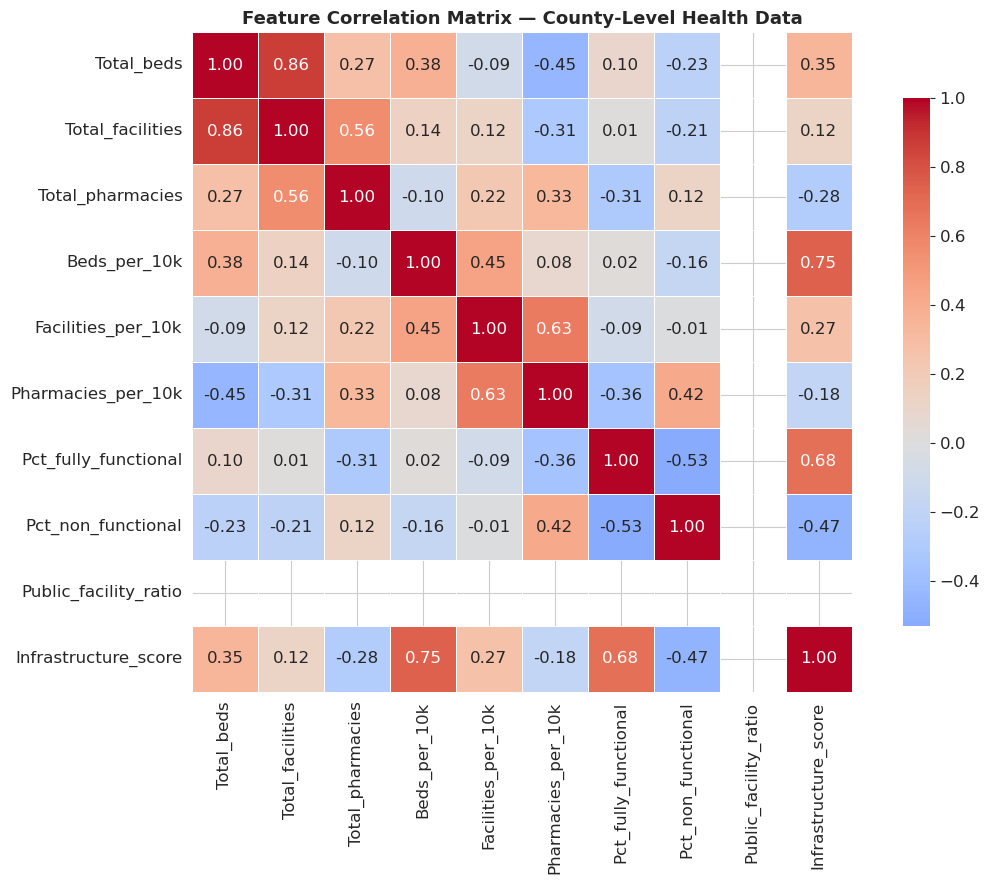

In [ ]:

numeric_cols = [
    'Total_beds', 'Total_facilities', 'Total_pharmacies',
    'Beds_per_10k', 'Facilities_per_10k', 'Pharmacies_per_10k',
    'Pct_fully_functional', 'Pct_non_functional',
    'Public_facility_ratio', 'Infrastructure_score'
]
 
corr = master[numeric_cols].corr()
 
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix: County-Level Health Data',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150)
plt.show()

In [ ]:

master = master.drop(columns=['Score_beds', 'Score_functional', 'Score_public'])
 
master.to_csv('../data/processed/county_master.csv', index=False)
 
print('Master table saved to data/processed/county_master.csv')
print('Shape:', master.shape)
print('Columns:', list(master.columns))

Master table saved to data/processed/county_master.csv
Shape: (47, 23)
Columns: ['County', 'Total_beds', 'Total_facilities', 'closed', 'fully-functional', 'non-functional', 'semi-functional', 'Total_health_units', 'Pct_fully_functional', 'Pct_non_functional', 'Total_pharmacies', 'Registered_pharmacies', 'Pct_pharmacies_registered', 'Public_facilities', 'Total_for_ownership', 'Public_facility_ratio', 'Facility_reported_beds', 'Suspect_zero_bed_count', 'Population', 'Beds_per_10k', 'Facilities_per_10k', 'Pharmacies_per_10k', 'Infrastructure_score']
